# 4. Define churn empirically

**Step 1 of the churn project.**

Retail is non-contractual: nobody cancels a subscription, they simply stop coming back. So the
data holds no churn label, and we have to construct one from the way customers space out their
purchases rather than from a round number plucked out of the air.

This notebook lays out the evidence before it chooses — the distribution of gaps between
purchases, each customer's own buying rhythm, and how many customers each candidate cut-off would
label as churned. The threshold is settled at the end, on those numbers, and the reasoning is
written out in full so it can be argued with.

*Expects `data.csv`, produced by `get_data.py`.*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load the data and clean it as little as possible

We strip out only the rows that are unarguably not a genuine purchase by an identifiable customer.
Anything more opinionated belongs to the later steps.

In [2]:
df = pd.read_csv("data.csv", encoding="utf-8", parse_dates=["InvoiceDate"],
                 date_format="%m/%d/%Y %H:%M")
start_rows = len(df)
print(f"Loaded: {start_rows:,} rows")


def drop(mask, reason):
    # Remove the rows matching the mask and report the cost, so every discarded
    # row is accounted for rather than disappearing silently.
    global df
    n = int(mask.sum())
    df = df[~mask]
    print(f"  - {reason}: removed {n:,} ({n / start_rows * 100:.1f}%)  ->  {len(df):,} remain")


# Each mask is built against df as it stands at that moment, because every call
# to drop() reassigns df. Building them all up front would test the wrong rows.

# No CustomerID means we cannot attribute the purchase to anyone.
missing_customer = df["CustomerID"].isna()
drop(missing_customer, "no CustomerID")

# Invoices starting with 'C' are cancellations - reversals of demand, not demand.
invoice_as_text = df["InvoiceNo"].astype(str)
is_cancellation = invoice_as_text.str.startswith("C")
drop(is_cancellation, "cancellations (InvoiceNo 'C')")

# Non-positive quantity is a return or adjustment; non-positive price is a giveaway or error.
non_positive_quantity = df["Quantity"] <= 0
drop(non_positive_quantity, "non-positive Quantity")

non_positive_price = df["UnitPrice"] <= 0
drop(non_positive_price, "non-positive UnitPrice")

print(f"Clean: {len(df):,} rows ({len(df) / start_rows * 100:.1f}% of the original)")

Loaded: 541,909 rows
  - no CustomerID: removed 135,080 (24.9%)  ->  406,829 remain
  - cancellations (InvoiceNo 'C'): removed 8,905 (1.6%)  ->  397,924 remain
  - non-positive Quantity: removed 0 (0.0%)  ->  397,924 remain
  - non-positive UnitPrice: removed 40 (0.0%)  ->  397,884 remain
Clean: 397,884 rows (73.4% of the original)


## 2. Date range

The final date is the anchor for churn: "silent for N days" is always measured back from the last
day on which we have any visibility at all.

In [3]:
end_date = df["InvoiceDate"].max()
start = df["InvoiceDate"].min()
print(f"{start.date()}  ->  {end_date.date()}   ({(end_date - start).days} days)")

2010-12-01  ->  2011-12-09   (373 days)


## 3. Collapse to one purchase per customer per day

A basket of twenty line items on a single invoice is one shopping trip, not twenty purchases. We
collapse to the calendar day, so two invoices on the same day still count as one purchase occasion
— the unit a customer would recognise.

In [4]:
# Collapse line items to purchase occasions
timestamps = df["InvoiceDate"]              # 397,884 timestamps, one per line item
days = timestamps.dt.normalize()            # 08:26 -> 00:00, same calendar day
df_with_day = df.assign(day=days)           # copy of df with the new column attached

grouped = df_with_day.groupby(["CustomerID", "day"])   # lazy: buckets, nothing computed
counts = grouped.size()                     # rows per bucket -> Series with a MultiIndex
purchases = counts.reset_index(name="lines")  # flatten -> CustomerID | day | lines

print(f"{len(purchases):,} customer-days across {purchases['CustomerID'].nunique():,} customers")

16,763 customer-days across 4,338 customers


## 4. Measure the gaps between consecutive purchases

A customer with only one purchase has no rhythm to measure, so there is no gap to compute. We set
those customers aside here and pick them up again in section 6.

In [5]:
purchases = purchases.sort_values(["CustomerID", "day"])

# Gap = days since that customer's own previous purchase.
day_by_customer = purchases.groupby("CustomerID")["day"]
gap_as_timedelta = day_by_customer.diff()   # NaT for each customer's first purchase
purchases["gap"] = gap_as_timedelta.dt.days  # Timedelta -> whole days

gaps = purchases["gap"].dropna()  # each customer's first purchase has no earlier gap

occasions = purchases.groupby("CustomerID")["day"].count()
has_two_or_more = occasions.gt(1)
repeat_customers = int(has_two_or_more.sum())
print(f"{repeat_customers:,} customers have 2+ purchases; {len(gaps):,} gaps computed")

2,790 customers have 2+ purchases; 12,425 gaps computed


## 5. Distribution of the gaps

Two views matter. The first pools every gap together and shows the raw cadence of the business.
The second takes each customer's own median gap — because a weekly buyer and a twice-a-year buyer
both look perfectly normal, and a single pooled figure hides the fact that a threshold fair to one
is brutal to the other.

In [6]:
pct = [50, 75, 90, 95]
print("Gap distribution (all gaps pooled):")
for p in pct:
    print(f"  {p}th percentile: {gaps.quantile(p / 100):.0f} days")
print(f"  mean: {gaps.mean():.0f} days   max: {gaps.max():.0f} days")

# One median per customer, then the spread of those medians. Pooling every gap
# instead would over-weight frequent buyers, who contribute far more gaps each.
gap_by_customer = purchases.groupby("CustomerID")["gap"]
median_gap_per_customer = gap_by_customer.median()
cust_median_gap = median_gap_per_customer.dropna()  # single-purchase customers have none

print("\nEach customer's own median gap (their typical spacing):")
for p in pct:
    print(f"  {p}th percentile: {cust_median_gap.quantile(p / 100):.0f} days")

Gap distribution (all gaps pooled):
  50th percentile: 28 days
  75th percentile: 58 days
  90th percentile: 110 days
  95th percentile: 155 days
  mean: 46 days   max: 366 days

Each customer's own median gap (their typical spacing):
  50th percentile: 52 days
  75th percentile: 97 days
  90th percentile: 166 days
  95th percentile: 224 days


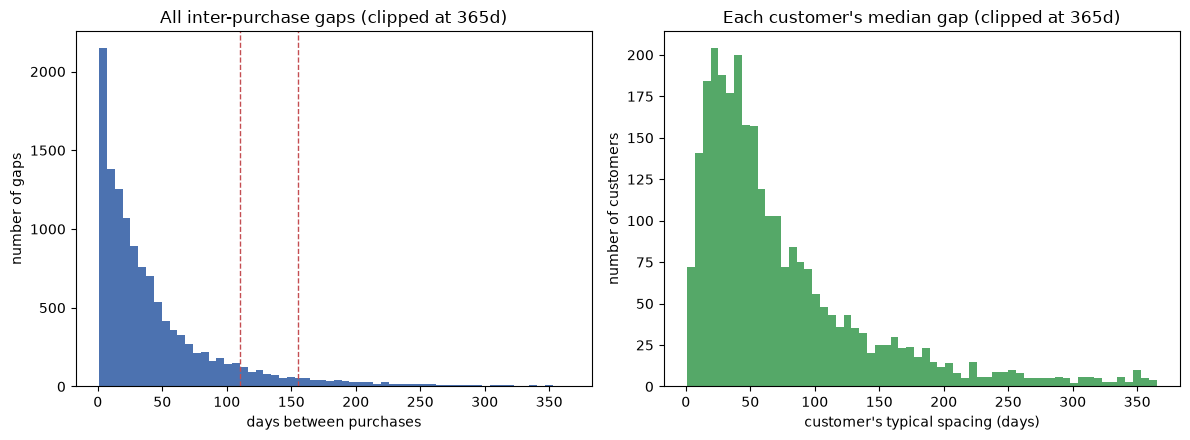

In [7]:
# Clip the long tail at 365 days so the bulk of the distribution stays legible;
# the percentiles above already summarise that tail.
gaps_clipped = gaps.clip(upper=365)
cust_median_gap_clipped = cust_median_gap.clip(upper=365)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].hist(gaps_clipped, bins=60, color="#4C72B0")
ax[0].set(title="All inter-purchase gaps (clipped at 365d)",
          xlabel="days between purchases", ylabel="number of gaps")
for p in (90, 95):  # mark the upper percentiles, where a sensible threshold sits
    percentile_value = gaps.quantile(p / 100)
    ax[0].axvline(percentile_value, color="#C44E52", ls="--", lw=1)

ax[1].hist(cust_median_gap_clipped, bins=60, color="#55A868")
ax[1].set(title="Each customer's median gap (clipped at 365d)",
          xlabel="customer's typical spacing (days)", ylabel="number of customers")

fig.tight_layout()
plt.show()

## 6. How many customers would be labelled churned at each candidate

Recency is the number of silent days at the end of the period. A candidate threshold *T* labels a
customer churned if their last purchase was more than *T* days before the end date. We report two
bases: the **full base** is every clean customer; the **repeat base** is only those with two or more
purchases. A single-purchase customer still has a recency, but their silence is ambiguous — they may
have bought once and vanished, or joined near the end and simply not returned yet — so we report that
group's size separately.

In [8]:
# Recency = days of silence at the end of the observation period.
last_purchase = purchases.groupby("CustomerID")["day"].max()
silence_as_timedelta = end_date - last_purchase
recency = silence_as_timedelta.dt.days
n_full = len(recency)

# The repeat base excludes anyone with a single purchase, whose silence is ambiguous.
is_repeat = occasions > 1
repeat_ids = occasions[is_repeat].index
recency_repeat = recency.loc[repeat_ids]
n_repeat = len(recency_repeat)
n_single = int((occasions == 1).sum())

print(f"Full base: {n_full:,} customers.  Repeat base: {n_repeat:,}.  "
      f"Single-purchase: {n_single:,} ({n_single / n_full * 100:.0f}% of full base).")
print(f"{'threshold':>9} | {'full base':>16} | {'repeat base':>16}")
print(f"{'':>9} | {'churned':>8} {'%':>7} | {'churned':>8} {'%':>7}")
for t in (60, 90, 120, 180):
    silent_full = recency > t
    silent_repeat = recency_repeat > t
    cf = int(silent_full.sum())
    cr = int(silent_repeat.sum())
    print(f"{t:>6}d   | {cf:>8,} {cf / n_full * 100:>6.1f}% "
          f"| {cr:>8,} {cr / n_repeat * 100:>6.1f}%")

Full base: 4,338 customers.  Repeat base: 2,790.  Single-purchase: 1,548 (36% of full base).
threshold |        full base |      repeat base
          |  churned       % |  churned       %
    60d   |    1,928   44.4% |      847   30.4%
    90d   |    1,449   33.4% |      571   20.5%
   120d   |    1,215   28.0% |      412   14.8%
   180d   |      858   19.8% |      218    7.8%


## Trade-off, and the threshold chosen

A **low threshold (60d)** catches customers early, but it also flags the ordinary occasional buyer
who was always going to come back. Those are false alarms.

A **high threshold (180d)** is almost always right — the customer really has gone — but the label
arrives late, leaving little time to act, and the churned group becomes small.

A defensible threshold sits **beyond the typical buying rhythm**, and should be read off the gap
percentiles in section 5 rather than picked as a round number. Above the 90th–95th percentile a gap
is no longer normal spacing; it starts to signal that the customer has stopped.

### **Decision: Churn Threshold is 90 days**

**Reasoning**

**1. It matches the benchmark.** Step 4 prices the obvious no-model rule — *contact everyone silent
for 90 days*. If the label were set at 120 days while the rule fired at 90, the model and the rule
would be answering two different questions and the comparison between them would mean nothing.
This is the decisive reason, and it is worth being honest that it is a pragmatic one rather than a
property of the data.

**2. Ninety days is already beyond normal spacing for most customers.** From section 5 it sits
between the 75th percentile of pooled gaps (58d) and the 90th (110d), and just below the 75th
percentile of customers' own median gaps (97d). So for roughly seven customers in ten, 90 days of
silence is longer than their own typical rhythm — unusual, without yet being terminal.

**3. It leaves a larger positive class.** 571 repeat customers are labelled churned at 90 days
against 412 at 120 days. More positives make the estimates in the later steps steadier, and the
observation window stays longer too (283 days against 253), so the features have more history
behind them.

**4. It leaves time to act.** A label that arrives at 120 or 180 days is more likely to be right
and less likely to be useful. The point of predicting churn is to have room to do something about
it.

**What this costs.** Choosing 90 over 120 knowingly accepts more false alarms: some of those 571
are occasional buyers who would have come back unprompted, and contacting them is wasted money.
That is not a reason to prefer 120 — it is a reason to price the error rather than argue about it,
which is exactly what step 3 does. If the pricing shows the false alarms swamp the savings, this
decision gets revisited on the evidence.

**The load-bearing assumption** is that a customer's past inter-purchase gaps are a valid proxy for
the future "stopped buying" we cannot observe. If buying behaviour changed structurally after the
data ends, the threshold is wrong, and nothing in this dataset can test that.

*This is step 1 of the project. No model has been built.*